# 🧠 Pipeline Completo — Detecção de Crises Epilépticas (CHB-MIT)
Este notebook unificado cobre **todo o pipeline** de ponta a ponta, dividido em capítulos distintos:

| # | Capítulo | Descrição |
|---|---------|-----------|
| 1 | Instalação & Imports | Dependências e caminhos |
| 2 | Carregamento dos Dados | Leitura dos EDFs + mapeamento de crises |
| 3 | Filtragem do Sinal | Filtros Notch e Butterworth banda 0.5–40 Hz |
| 4 | Extração de Features | DWT (Haar) + FFT por paciente |
| 5 | Consolidação | `.npy` por trial e global por paciente |
| 6 | Divisão de Dados | LOOCV (trial-a-trial) |
| 7 | Treino | XGBoost · Random Forest · SVM (paralelo) |
| 8 | Resultados | Métricas por trial e por paciente |
| 9 | Análise Diagnóstica | Foco no chb04 (sensitividade baixa) + dicas |

> **Dataset:** CHB-MIT Scalp EEG — https://physionet.org/content/chbmit/  
> **Canais usados:** F7-T7, T7-P7, F8-T8, T8-P8 (região temporal, sensível a crises)  
> **Pacientes:** chb01 a chb05


---
# Capítulo 1 — Instalação e Imports ( Python 3.13.2 )

In [1]:
%pip install numpy pandas mne PyWavelets scikit-learn xgboost joblib tqdm scipy matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import os, time, warnings
from contextlib import contextmanager

import mne
from scipy.signal import butter, filtfilt, iirnotch, sosfiltfilt, butter as _butter
import pywt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

import joblib
from joblib import Parallel, delayed
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

# ── Reprodutibilidade ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Imports OK')


c:\Users\danil\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports OK


Download do dataset, paciente 1 ao 5

In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import os

bucket = "physionet-open"
base_prefix = "chbmit/1.0.0/"
local_root = "data"

os.makedirs(local_root, exist_ok=True)

s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
paginator = s3.get_paginator("list_objects_v2")

# Baixa arquivo de referência usado pelo pipeline (se ainda não existir localmente)
records_key = base_prefix + "RECORDS-WITH-SEIZURES"
records_local = os.path.join(local_root, "RECORDS-WITH-SEIZURES")
if os.path.exists(records_local):
    print("Skipping (já existe):", records_local)
else:
    print("Downloading", records_key)
    s3.download_file(bucket, records_key, records_local)

# Baixa chb01 até chb05
for patient_idx in range(1, 6):
    patient = f"chb{patient_idx:02d}"
    prefix = f"{base_prefix}{patient}/"
    local_dir = os.path.join(local_root, patient)
    os.makedirs(local_dir, exist_ok=True)

    print(f"\n=== Verificando {patient} ===")
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]

            if key.endswith("/"):
                continue

            local_path = os.path.join(local_dir, os.path.basename(key))
            if os.path.exists(local_path):
                print("Skipping (já existe):", local_path)
                continue

            print("Downloading", key)
            s3.download_file(bucket, key, local_path)

print("\nDownload concluído para chb01 até chb05 (sem duplicar arquivos já existentes).")

In [3]:
# ════════════════════════════════════════════════════════════
# AJUSTE ESTES CAMINHOS CONFORME SUA MÁQUINA
# ════════════════════════════════════════════════════════════
data_dir  = 'c:/Users/danil/OneDrive/Documentos/nutes/eeg/Artifact-Seizure/Seizure_Detection/data/'
data_save = 'c:/Users/danil/OneDrive/Documentos/nutes/eeg/Artifact-Seizure/Seizure_Detection/data_processed/'

os.makedirs(data_save, exist_ok=True)
os.makedirs('results/subject_specific/', exist_ok=True)
os.makedirs('results/global/', exist_ok=True)

print(f'data_dir  → {data_dir}')
print(f'data_save → {data_save}')


data_dir  → c:/Users/danil/OneDrive/Documentos/nutes/eeg/Artifact-Seizure/Seizure_Detection/data/
data_save → c:/Users/danil/OneDrive/Documentos/nutes/eeg/Artifact-Seizure/Seizure_Detection/data_processed/


---
# Capítulo 2 — Carregamento dos Dados

Lemos a estrutura do CHB-MIT e montamos um dicionário com os intervalos de crise em segundos.
A conversão para amostras é feita usando a frequência real (`sfreq`) de cada EDF.

**Frequência de amostragem:** lida de cada arquivo EDF (no CHB-MIT costuma ser 256 Hz)  
**Arquivo de referência:** `chbXX-summary.txt` (contém início/fim de crises em segundos)


In [4]:
patients = sorted([p for p in os.listdir(data_dir) if p.startswith('chb')])
# Mantém apenas chb01–chb05
patients = [p for p in patients if 1 <= int(p[3:]) <= 5]
print('Pacientes:', patients)

seizure_files_df = pd.read_csv(os.path.join(data_dir, 'RECORDS-WITH-SEIZURES'), header=None)
seizure_files = [f[6:] for f in seizure_files_df[0]]  # remove prefixo 'chbXX/'

summary_paths = [os.path.join(data_dir, p, p + '-summary.txt') for p in patients]

patient_seizure_dict = {}

for i, patient in enumerate(patients):
    seizure_dict = {}
    summary = pd.read_csv(summary_paths[i], sep='\t', header=None)
    summary = summary[0].str.lower()

    patient_files = [f for f in seizure_files if f.startswith(patient)]

    for sf in patient_files:
        times_sec = []
        line = summary[summary.str.contains(sf)].index[0]
        num_seizures = int(summary[line + 3].split(': ')[1])
        for j in range(num_seizures):
            s_sec = float(summary[line + 4 + 2*j].split(': ')[1].strip().split(' ')[0])
            e_sec = float(summary[line + 4 + 2*j + 1].split(': ')[1].strip().split(' ')[0])
            times_sec.append([s_sec, e_sec])
        seizure_dict[sf] = times_sec

    patient_seizure_dict[patient] = seizure_dict
    print(f'  {patient}: {len(seizure_dict)} arquivo(s) com crise')

print('\n✅ Dicionário de crises montado (intervalos em segundos).')


Pacientes: ['chb01', 'chb02', 'chb03', 'chb04', 'chb05']
  chb01: 7 arquivo(s) com crise
  chb02: 3 arquivo(s) com crise
  chb03: 7 arquivo(s) com crise
  chb04: 3 arquivo(s) com crise
  chb05: 5 arquivo(s) com crise

✅ Dicionário de crises montado (intervalos em segundos).


---
# Capítulo 3 — Filtragem do Sinal EEG

## Por que filtrar?

Sinais de EEG registrados com eletrodos de couro cabeludo sofrem de várias fontes de ruído.
Três filtros são padrão na literatura de epilepsia:

| Filtro | Tipo | Frequência | Finalidade |
|--------|------|-----------|-----------|
| **Notch 60 Hz** | IIR (Q=30) | 60 Hz | Remove interferência da rede elétrica (EUA/Canadá = 60 Hz) |
| **Passa-alta 0.5 Hz** | Butterworth 4ª ordem | >0.5 Hz | Remove deriva DC e artefatos de movimento lentos |
| **Passa-baixa 40 Hz** | Butterworth 4ª ordem | <40 Hz | Remove EMG (eletromiografia muscular) e ruído de alta freq. |

A faixa **0.5–40 Hz** captura as principais bandas epilépticas (theta 4–8, alpha 8–13, beta 13–30)
e inclui os padrões ictal de alta amplitude que caracterizam as crises.

> ⚠️ O CHB-MIT foi gravado nos EUA → ruído de rede em **60 Hz**.  
> Se for um dataset europeu, troque o filtro Notch para **50 Hz**.


In [5]:
def aplicar_filtros(raw_data, fs=256):
    """
    Aplica a cadeia de filtragem padrão para EEG epiléptico:
      1. Notch 60 Hz  (interferência da rede elétrica — padrão USA)
      2. Passa-alta  0.5 Hz  (remove deriva DC e movimento lento)
      3. Passa-baixa 40 Hz   (remove EMG e ruído de alta frequência)

    raw_data : np.ndarray shape (n_amostras, n_canais)
    Retorna  : np.ndarray shape (n_amostras, n_canais) filtrado
    """
    filtered = raw_data.copy()

    # 1) Notch 60 Hz
    b_n, a_n = iirnotch(60.0, Q=30.0, fs=fs)
    filtered  = filtfilt(b_n, a_n, filtered, axis=0)

    # 2) Passa-alta 0.5 Hz
    b_hp, a_hp = butter(4, 0.5 / (fs / 2), btype='high')
    filtered    = filtfilt(b_hp, a_hp, filtered, axis=0)

    # 3) Passa-baixa 40 Hz
    b_lp, a_lp = butter(4, 40.0 / (fs / 2), btype='low')
    filtered    = filtfilt(b_lp, a_lp, filtered, axis=0)

    return filtered

print('✅ Função de filtragem definida.')
print('   Cadeia: Notch 60 Hz → Butterworth HP 0.5 Hz → Butterworth LP 40 Hz')


✅ Função de filtragem definida.
   Cadeia: Notch 60 Hz → Butterworth HP 0.5 Hz → Butterworth LP 40 Hz


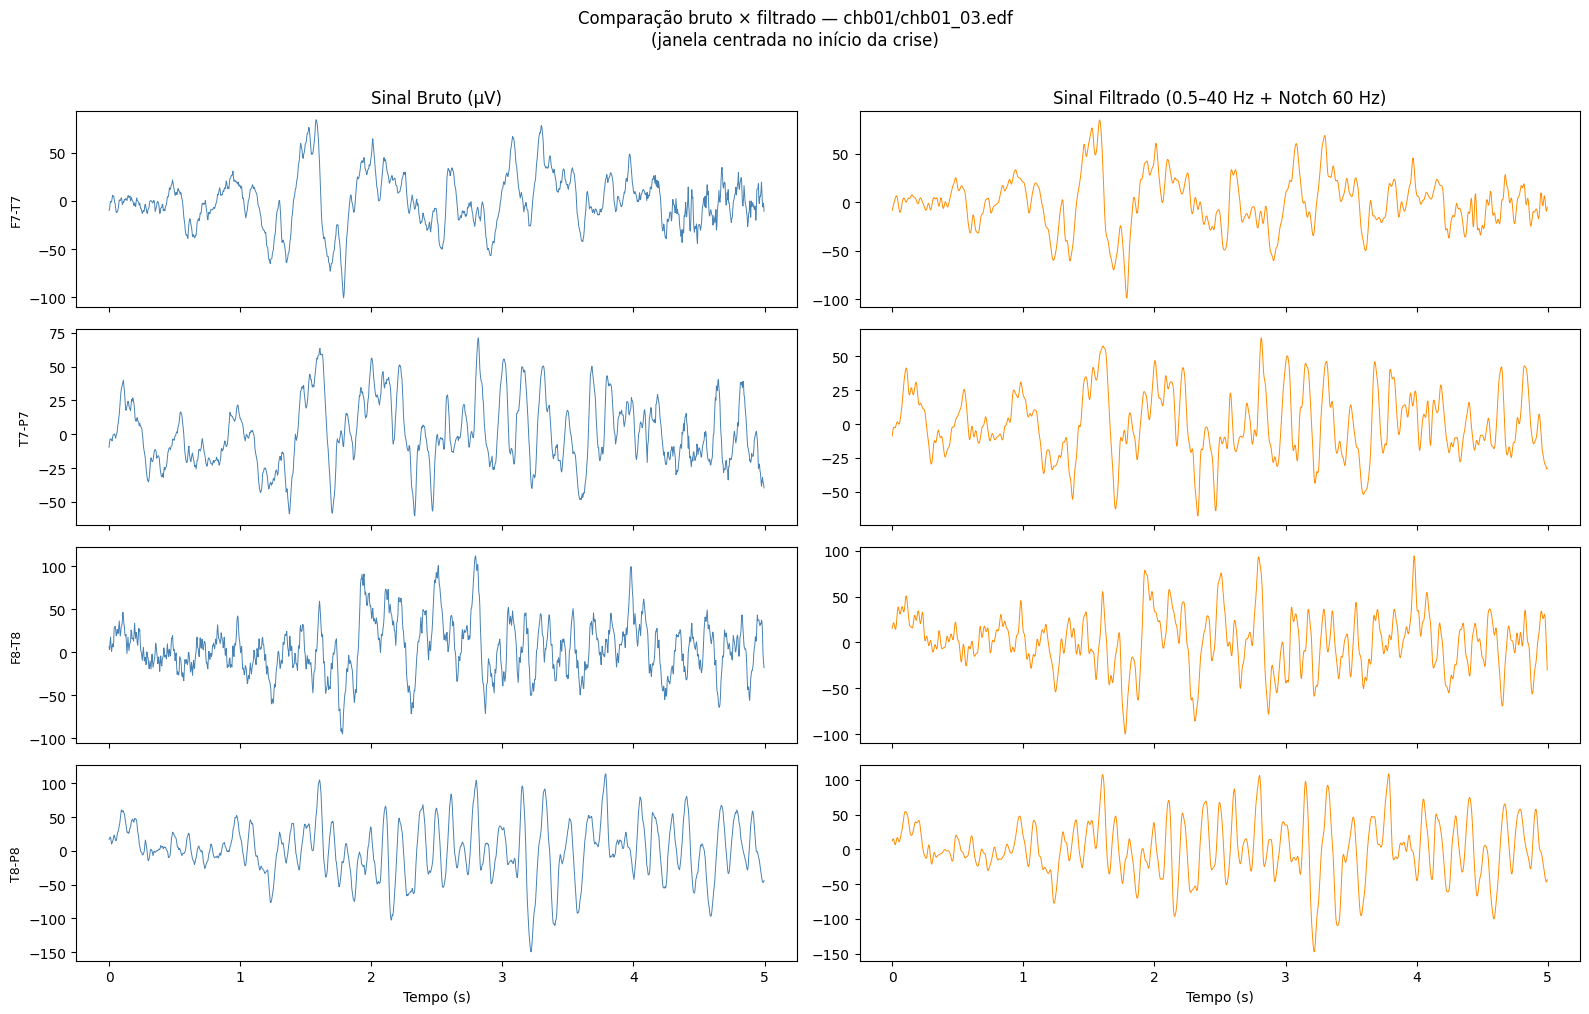

✅ Gráfico salvo em results/filtro_comparacao.png


In [6]:
# ── Visualização: sinal bruto vs. filtrado (exemplo no 1º arquivo do chb01) ─
example_patient = 'chb01'
example_file = list(patient_seizure_dict[example_patient].keys())[0]

raw_mne = mne.io.read_raw_edf(
    data_dir + example_patient + '/' + example_file,
    include=['F7-T7', 'T7-P7', 'F8-T8', 'T8-P8'],
    verbose=False
)
fs_example = float(raw_mne.info['sfreq'])
raw_np = raw_mne.get_data() * 1e6   # V → µV
raw_np = np.transpose(raw_np)        # (amostras, canais)
if raw_np.shape[1] == 5:
    raw_np = raw_np[:, :4]

filt_np = aplicar_filtros(raw_np, fs=fs_example)

# Pega um trecho de 5 s centrado no início da 1ª crise
sz_start_sec = patient_seizure_dict[example_patient][example_file][0][0]
sz_start = int(sz_start_sec * fs_example)
t0 = max(0, sz_start - int(2 * fs_example))
t1 = sz_start + int(3 * fs_example)
t_axis = np.arange(t1 - t0) / fs_example

fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex=True)
ch_names = ['F7-T7', 'T7-P7', 'F8-T8', 'T8-P8']
for ch in range(4):
    axes[ch, 0].plot(t_axis, raw_np[t0:t1, ch], lw=0.7, color='steelblue')
    axes[ch, 1].plot(t_axis, filt_np[t0:t1, ch], lw=0.7, color='darkorange')
    axes[ch, 0].set_ylabel(ch_names[ch], fontsize=9)

axes[0, 0].set_title('Sinal Bruto (µV)')
axes[0, 1].set_title('Sinal Filtrado (0.5–40 Hz + Notch 60 Hz)')
axes[-1, 0].set_xlabel('Tempo (s)')
axes[-1, 1].set_xlabel('Tempo (s)')
plt.suptitle(f'Comparação bruto × filtrado — {example_patient}/{example_file}\n(janela centrada no início da crise)', y=1.01)
plt.tight_layout()
plt.savefig('results/filtro_comparacao.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo em results/filtro_comparacao.png')


---
# Capítulo 4 — Extração de Features

Duas famílias de features são extraídas em janelas deslizantes de 1, 2, 4 e 8 segundos:

## 4.1 DWT — Discrete Wavelet Transform (Haar, nível 4)
Decompõe o sinal em 4 sub-bandas de detalhe (cD1…cD4).  
Feature = **energia** de cada sub-banda = Σ(coef²).  
Para 4 canais × 4 sub-bandas → **16 features** por janela.

## 4.2 FFT — Power acima de 80 Hz (artefato muscular)
Calcula a potência espectral acima de 80 Hz por canal.  
Serve como feature auxiliar de ruído/artefato.  
Para 4 canais → **4 features** por janela.


In [7]:
# ══ Funções de extração (versão integrada com filtragem) ══════════════════════

def dwt_calc(data, window_length, level=4):
    """
    Extrai energia das 4 sub-bandas de detalhe da DWT Haar.
    data : (n_amostras, n_canais) — já filtrado
    Retorna : (n_janelas, n_canais * 4)
    """
    c, PC = data.shape
    n_win = int(np.floor(c / window_length))
    wname = 'haar'

    all_feats = []
    for w in range(n_win):
        seg = data[w*window_length:(w+1)*window_length, :]
        feats = []
        for ch in range(PC):
            coeffs = pywt.wavedec(seg[:, ch], wname, level=level)
            # coeffs = [cA4, cD4, cD3, cD2, cD1]
            for d in coeffs[1:]:   # cD4, cD3, cD2, cD1
                feats.append(np.sum(d**2))
        all_feats.append(feats)
    return np.array(all_feats)   # (n_win, 16)


def fft_power_calc(data, sec, fs=256):
    """
    Potência espectral acima de 80 Hz por canal.
    data : (n_amostras, n_canais)
    Retorna : (n_janelas, n_canais)
    """
    samples_per_win = int(round(sec * fs))
    n_win = int(np.floor(data.shape[0] / samples_per_win))
    feats = []
    for w in range(n_win):
        seg = data[w*samples_per_win:(w+1)*samples_per_win, :]
        row = []
        for ch in range(seg.shape[1]):
            X_pow = np.abs(np.fft.fft(seg[:, ch]))**2
            N = seg.shape[0]
            row.append(np.sqrt(np.sum(X_pow[int(80/(fs/N)):N//2])))
        feats.append(row)
    return np.array(feats)   # (n_win, 4)


def make_labels(labels, fs, length):
    """Converte labels por amostra em labels por janela (maioria simples)."""
    fs = int(round(fs))
    win_size = fs * length
    n_win = int(np.floor(labels.shape[0] / win_size))
    out = []
    for i in range(n_win):
        out.append(1 if np.sum(labels[i*win_size:(i+1)*win_size]) > fs/2 else 0)
    return np.array(out)


print('✅ Funções de feature extraction definidas.')


✅ Funções de feature extraction definidas.


---
# Capítulo 5 — Consolidação: Extração e Salvamento dos .npy

Para cada arquivo de crise de cada paciente:
1. Lê o EDF
2. **Aplica os filtros** (Notch + BP 0.5–40 Hz)
3. Extrai features DWT e FFT
4. Salva `.npy` por trial

Depois consolida em `global_features_Xs.npy` por paciente.

> **Atenção:** esta célula só processa arquivos ainda não existentes (skip automático).


In [8]:
seconds = [4]  # Janela de 4s (melhor resultado segundo o artigo)

for patient in patient_seizure_dict:
    print(f'\n📂 {patient}')
    os.makedirs(os.path.join(data_save, patient), exist_ok=True)

    for seizure_file in patient_seizure_dict[patient]:
        edf_path = os.path.join(data_dir, patient, seizure_file)

        try:
            raw_mne = mne.io.read_raw_edf(
                edf_path, include=['F7-T7','T7-P7','F8-T8','T8-P8'], verbose=False)
            fs_file = float(raw_mne.info['sfreq'])
            raw_data = raw_mne.get_data() * 1e6          # V → µV
            raw_data = np.transpose(raw_data)             # (amostras, canais)
            if raw_data.shape[1] == 5:
                raw_data = raw_data[:, :4]
        except Exception as e:
            print(f'  ⚠️  Erro ao ler {seizure_file}: {e}')
            continue

        # ── Filtragem ──────────────────────────────────────────────────────────
        raw_data = aplicar_filtros(raw_data, fs=fs_file)

        # ── Labels por amostra (a partir de intervalos em segundos) ───────────
        labels = np.zeros(raw_data.shape[0])
        for [s_sec, e_sec] in patient_seizure_dict[patient][seizure_file]:
            s = max(0, int(np.floor(s_sec * fs_file)))
            e = min(labels.shape[0], int(np.ceil(e_sec * fs_file)))
            if e > s:
                labels[s:e] = 1

        # ── Salva por janela temporal ──────────────────────────────────────────
        base = os.path.join(data_save, patient, seizure_file[:-4])
        fs_int = int(round(fs_file))
        for sec in seconds:
            lbl_path = f'{base}_labels_{sec}s.npy'
            dwt_path = f'{base}_features_{sec}s.npy'
            fft_path = f'{base}_features_fft_{sec}s.npy'

            if not os.path.exists(lbl_path):
                np.save(lbl_path, make_labels(labels, fs_int, sec))

            if not os.path.exists(dwt_path):
                np.save(dwt_path, dwt_calc(raw_data, fs_int * sec))

            if not os.path.exists(fft_path):
                np.save(fft_path, fft_power_calc(raw_data, sec, fs=fs_file))

        print(f'  ✓  {seizure_file} (sfreq={fs_file:.2f} Hz)')

print('\n✅ Extração por trial concluída.')



📂 chb01
  ✓  chb01_03.edf (sfreq=256.00 Hz)
  ✓  chb01_04.edf (sfreq=256.00 Hz)
  ✓  chb01_15.edf (sfreq=256.00 Hz)
  ✓  chb01_16.edf (sfreq=256.00 Hz)
  ✓  chb01_18.edf (sfreq=256.00 Hz)
  ✓  chb01_21.edf (sfreq=256.00 Hz)
  ✓  chb01_26.edf (sfreq=256.00 Hz)

📂 chb02
  ✓  chb02_16.edf (sfreq=256.00 Hz)
  ✓  chb02_16+.edf (sfreq=256.00 Hz)
  ✓  chb02_19.edf (sfreq=256.00 Hz)

📂 chb03
  ✓  chb03_01.edf (sfreq=256.00 Hz)
  ✓  chb03_02.edf (sfreq=256.00 Hz)
  ✓  chb03_03.edf (sfreq=256.00 Hz)
  ✓  chb03_04.edf (sfreq=256.00 Hz)
  ✓  chb03_34.edf (sfreq=256.00 Hz)
  ✓  chb03_35.edf (sfreq=256.00 Hz)
  ✓  chb03_36.edf (sfreq=256.00 Hz)

📂 chb04
  ✓  chb04_05.edf (sfreq=256.00 Hz)
  ✓  chb04_08.edf (sfreq=256.00 Hz)
  ✓  chb04_28.edf (sfreq=256.00 Hz)

📂 chb05
  ✓  chb05_06.edf (sfreq=256.00 Hz)
  ✓  chb05_13.edf (sfreq=256.00 Hz)
  ✓  chb05_16.edf (sfreq=256.00 Hz)
  ✓  chb05_17.edf (sfreq=256.00 Hz)
  ✓  chb05_22.edf (sfreq=256.00 Hz)

✅ Extração por trial concluída.


In [9]:
# ── Consolidação por paciente (global) ────────────────────────────────────────
for patient in patient_seizure_dict:
    print(f'Consolidando {patient}...')
    p_dir  = os.path.join(data_save, patient)
    files  = os.listdir(p_dir)

    for sec in seconds:
        # DWT + labels
        feats_list  = sorted([f for f in files if f.endswith(f'features_{sec}s.npy')   and not f.startswith('global')])
        labels_list = sorted([f for f in files if f.endswith(f'labels_{sec}s.npy')      and not f.startswith('global')])
        fft_list    = sorted([f for f in files if f.endswith(f'features_fft_{sec}s.npy') and not f.startswith('global')])

        if feats_list:
            feat_all  = np.concatenate([np.load(os.path.join(p_dir, f)) for f in feats_list])
            label_all = np.concatenate([np.load(os.path.join(p_dir, f)) for f in labels_list])
            np.save(os.path.join(p_dir, f'global_features_{sec}s.npy'),  feat_all)
            np.save(os.path.join(p_dir, f'global_labels_{sec}s.npy'),    label_all)

        if fft_list:
            fft_all = np.concatenate([np.load(os.path.join(p_dir, f)) for f in fft_list])
            np.save(os.path.join(p_dir, f'global_features_fft{sec}s.npy'), fft_all)

print('\n✅ Arquivos globais por paciente salvos.')


Consolidando chb01...
Consolidando chb02...
Consolidando chb03...
Consolidando chb04...
Consolidando chb05...

✅ Arquivos globais por paciente salvos.


In [10]:
# ── Consolidação final: todos os pacientes ────────────────────────────────────
for sec in seconds:
    all_feats, all_labels, all_fft = [], [], []
    for patient in patient_seizure_dict:
        p_dir = os.path.join(data_save, patient)
        f_p   = os.path.join(p_dir, f'global_features_{sec}s.npy')
        l_p   = os.path.join(p_dir, f'global_labels_{sec}s.npy')
        ff_p  = os.path.join(p_dir, f'global_features_fft{sec}s.npy')
        if os.path.exists(f_p):
            all_feats.append(np.load(f_p))
            all_labels.append(np.load(l_p))
        if os.path.exists(ff_p):
            all_fft.append(np.load(ff_p))

    if all_feats:
        np.save(os.path.join(data_save, f'global_features_{sec}s.npy'), np.concatenate(all_feats))
        np.save(os.path.join(data_save, f'global_labels_{sec}s.npy'),   np.concatenate(all_labels))
    if all_fft:
        np.save(os.path.join(data_save, f'global_features_fft{sec}s.npy'), np.concatenate(all_fft))

print('✅ Consolidação global (todos pacientes) concluída.')


✅ Consolidação global (todos pacientes) concluída.


---
# Capítulo 6 — Divisão dos Dados

## Estratégia LOOCV por Trial (Leave-One-Out Cross-Validation)

Para cada paciente, cada trial (arquivo EDF com crise) é usado uma vez como **conjunto de teste**,
enquanto todos os demais são usados como **treino**.

Isso garante que o modelo nunca veja dados do mesmo trial no treino — avaliação mais realista
do que um simples train_test_split.

Além disso, um **train_test_split 75/25 global** é mantido para comparação.


In [14]:
def _nome_npy(patient, trial, sec, sufixo):
    """Monta caminho do .npy, tratando o caso especial do chb17."""
    if patient == 'chb17':
        letra = 'b' if trial == '63' else 'a'
        return os.path.join(data_save, patient, f'{patient}{letra}_{trial}_{sufixo}_{sec}s.npy')
    return os.path.join(data_save, patient, f'{patient}_{trial}_{sufixo}_{sec}s.npy')


def carregar_loocv(patient, trials, idx_test, sec):
    """
    Retorna (X_train, y_train, X_test, y_test) para o fold idx_test.
    """
    X_tr_list, y_tr_list = [], []
    X_te, y_te = None, None

    for j, trial in enumerate(trials):
        feat = np.load(_nome_npy(patient, trial, sec, 'features'))
        lbl  = np.load(_nome_npy(patient, trial, sec, 'labels'))
        if j == idx_test:
            X_te, y_te = feat, lbl
        else:
            X_tr_list.append(feat)
            y_tr_list.append(lbl)

    return np.concatenate(X_tr_list), np.concatenate(y_tr_list), X_te, y_te


# ── Coleta trials disponíveis por paciente ─────────────────────────────────────
SECONDS_TRAIN = 4   # janela usada no treino principal

patient_trials = {}
for patient in patient_seizure_dict:
    p_dir    = os.path.join(data_save, patient)
    files    = os.listdir(p_dir)
    offset   = (7, 9) if patient == 'chb17' else (6, 8)
    trials = sorted({f[offset[0]:offset[1]] for f in files
                 if f.endswith(f'features_{SECONDS_TRAIN}s.npy') and f.startswith(patient)})
    patient_trials[patient] = trials
    print(f'{patient}: {len(trials)} trials — {trials}')

print('\n✅ Mapa de trials pronto.')


chb01: 7 trials — ['03', '04', '15', '16', '18', '21', '26']
chb02: 2 trials — ['16', '19']
chb03: 7 trials — ['01', '02', '03', '04', '34', '35', '36']
chb04: 3 trials — ['05', '08', '28']
chb05: 5 trials — ['06', '13', '16', '17', '22']

✅ Mapa de trials pronto.


---
# Capítulo 7 — Treino dos Modelos

## Modelos comparados
| Modelo | Hiperparâmetro de balanceamento | Observação |
|--------|-------------------------------|-----------|
| **XGBoost** | `scale_pos_weight` | Rápido, lida bem com desbalanceamento |
| **Random Forest** | `class_weight={0:1, 1:w}` | Robusto, boa baseline |
| **SVM (RBF)** | `class_weight={0:1, 1:w}` | Mais lento; busca esparsa de w |

## Por que ajustar o peso da classe positiva?
Crises representam < 5 % do sinal — o dataset é **muito desbalanceado**.  
Varrer o peso permite encontrar o ponto ótimo entre sensitividade e especificidade.

> ⚠️ chb04 obteve sensitividade ~30% com a configuração padrão.  
> O capítulo 9 investiga e sugere correções.


In [16]:
@contextmanager
def tqdm_joblib(tqdm_object):
    class _CB(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = _CB
    try:    yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old
        tqdm_object.close()


def calcular_metricas(y_true, y_pred):
    TP=FN=FP=TN = 0
    for p, t in zip(y_pred, y_true):
        if   p==1 and t==1: TP+=1
        elif p==1 and t==0: FP+=1
        elif p==0 and t==0: TN+=1
        else:               FN+=1
    sens = TP/(TP+FN)*100 if (TP+FN) else 0.
    spec = TN/(TN+FP)*100 if (TN+FP) else 0.
    acc  = (TP+TN)/(TP+TN+FP+FN)*100
    prec = TP/(TP+FP)*100 if (TP+FP) else 0.
    f1   = 2*prec*sens/(prec+sens) if (prec+sens) else 0.
    return acc, sens, spec, prec, f1


def treinar_xgboost(X_tr, y_tr, seed, X_te, y_te, weight, complexity):
    mdl = XGBClassifier(n_estimators=complexity, random_state=seed,
                        scale_pos_weight=weight, max_depth=15,
                        eval_metric='logloss', use_label_encoder=False, n_jobs=1)
    mdl.fit(X_tr, y_tr)
    return calcular_metricas(y_te, mdl.predict(X_te)) + (complexity, weight)


def treinar_rf(X_tr, y_tr, seed, X_te, y_te, weight, complexity):
    mdl = RandomForestClassifier(n_estimators=complexity, random_state=seed,
                                 class_weight={0:1, 1:weight}, max_depth=15, n_jobs=1)
    mdl.fit(X_tr, y_tr)
    return calcular_metricas(y_te, mdl.predict(X_te)) + (complexity, weight)


def treinar_svm(X_tr, y_tr, seed, X_te, y_te, weight):
    # SVM requer features normalizadas
    sc = StandardScaler()
    Xtr_sc = sc.fit_transform(X_tr)
    Xte_sc = sc.transform(X_te)
    mdl = SVC(kernel='rbf', random_state=seed, class_weight={0:1, 1:weight})
    mdl.fit(Xtr_sc, y_tr)
    return calcular_metricas(y_te, mdl.predict(Xte_sc)) + (weight,)


print('✅ Funções de treino e métricas definidas.')


✅ Funções de treino e métricas definidas.


In [18]:
# ── Configuração ──────────────────────────────────────────────────────────────
N_CORES      = 2
COMPLEXITY   = 100          # n_estimators para XGB e RF
LIST_WEIGHT  = list(range(1, 501))       # XGB e RF — varredura de 1 a 500
LIST_W_SVM   = list(range(1, 200, 10))  # SVM — busca esparsa

# ── Experimento 1: XGBoost LOOCV ──────────────────────────────────────────────
print('='*60)
print('Experimento 1 — XGBoost · LOOCV')
print('='*60)

for patient, trials in patient_trials.items():
    os.makedirs(f'results/subject_specific/{patient}', exist_ok=True)
    print(f'\n[XGB] {patient} — {len(trials)} trials')

    for i, trial_test in enumerate(trials):
        out = f'results/subject_specific/{patient}/{trial_test}_xgboost_loocv_{SECONDS_TRAIN}s.pkl'
        if os.path.exists(out):
            print(f'  trial {trial_test}: já existe, pulando.')
            continue

        X_tr, y_tr, X_te, y_te = carregar_loocv(patient, trials, i, SECONDS_TRAIN)
        t0 = time.time()
        with tqdm_joblib(tqdm(total=len(LIST_WEIGHT), desc=f'{patient} XGB trial {trial_test}')):
            result = Parallel(n_jobs=N_CORES)(
                delayed(treinar_xgboost)(X_tr, y_tr, RANDOM_STATE, X_te, y_te, w, COMPLEXITY)
                for w in LIST_WEIGHT)
        pd.DataFrame(result, columns=['accuracy','sensitivity','specificity','precision','f1','complexity','weight'])          .to_pickle(out)
        print(f'  trial {trial_test} → {out}  ({time.time()-t0:.1f}s)')


Experimento 1 — XGBoost · LOOCV

[XGB] chb01 — 7 trials


chb01 XGB trial 03: 100%|██████████| 500/500 [00:36<00:00, 13.56it/s]


  trial 03 → results/subject_specific/chb01/03_xgboost_loocv_4s.pkl  (37.0s)


chb01 XGB trial 04: 100%|██████████| 500/500 [00:33<00:00, 15.10it/s]


  trial 04 → results/subject_specific/chb01/04_xgboost_loocv_4s.pkl  (33.1s)


...

  trial 16 → results/subject_specific/chb05/16_xgboost_loocv_4s.pkl  (50.5s)


chb05 XGB trial 17: 100%|██████████| 500/500 [00:46<00:00, 10.67it/s]


  trial 17 → results/subject_specific/chb05/17_xgboost_loocv_4s.pkl  (46.9s)


chb05 XGB trial 22: 100%|██████████| 500/500 [00:44<00:00, 11.15it/s]

  trial 22 → results/subject_specific/chb05/22_xgboost_loocv_4s.pkl  (44.8s)


In [20]:
# ── Experimento 2: XGBoost Normal (train_test_split global) ──────────────────
print('='*60)
print('Experimento 2 — XGBoost · train_test_split global 75/25')
print('='*60)

feat_g  = np.load(os.path.join(data_save, f'global_features_{SECONDS_TRAIN}s.npy'))
label_g = np.load(os.path.join(data_save, f'global_labels_{SECONDS_TRAIN}s.npy'))

X_tr, X_te, y_tr, y_te = train_test_split(feat_g, label_g, test_size=0.25, random_state=RANDOM_STATE)

out = f'results/global/xgboost_normal_{SECONDS_TRAIN}s.pkl'
if not os.path.exists(out):
    t0 = time.time()
    with tqdm_joblib(tqdm(total=len(LIST_WEIGHT), desc='XGBoost Normal')):
        result = Parallel(n_jobs=N_CORES)(
            delayed(treinar_xgboost)(X_tr, y_tr, RANDOM_STATE, X_te, y_te, w, COMPLEXITY)
            for w in LIST_WEIGHT)
    pd.DataFrame(result, columns=['accuracy','sensitivity','specificity','precision','f1','complexity','weight'])      .to_pickle(out)
    print(f'Salvo: {out}  ({time.time()-t0:.1f}s)')
else:
    print('Já existe, pulando.')


Experimento 2 — XGBoost · train_test_split global 75/25


XGBoost Normal: 100%|██████████| 500/500 [03:44<00:00,  2.23it/s]

Salvo: results/global/xgboost_normal_4s.pkl  (224.6s)


In [21]:
# ── Experimento 3: Random Forest LOOCV ───────────────────────────────────────
print('='*60)
print('Experimento 3 — Random Forest · LOOCV')
print('='*60)

for patient, trials in patient_trials.items():
    os.makedirs(f'results/subject_specific/{patient}', exist_ok=True)
    print(f'\n[RF] {patient} — {len(trials)} trials')

    for i, trial_test in enumerate(trials):
        out = f'results/subject_specific/{patient}/{trial_test}_rf_loocv_{SECONDS_TRAIN}s.pkl'
        if os.path.exists(out):
            print(f'  trial {trial_test}: já existe, pulando.')
            continue

        X_tr, y_tr, X_te, y_te = carregar_loocv(patient, trials, i, SECONDS_TRAIN)
        t0 = time.time()
        with tqdm_joblib(tqdm(total=len(LIST_WEIGHT), desc=f'{patient} RF trial {trial_test}')):
            result = Parallel(n_jobs=N_CORES)(
                delayed(treinar_rf)(X_tr, y_tr, RANDOM_STATE, X_te, y_te, w, COMPLEXITY)
                for w in LIST_WEIGHT)
        pd.DataFrame(result, columns=['accuracy','sensitivity','specificity','precision','f1','complexity','weight'])          .to_pickle(out)
        print(f'  trial {trial_test} → {out}  ({time.time()-t0:.1f}s)')


Experimento 3 — Random Forest · LOOCV

[RF] chb01 — 7 trials


chb01 RF trial 03: 100%|██████████| 500/500 [03:03<00:00,  2.73it/s]


  trial 03 → results/subject_specific/chb01/03_rf_loocv_4s.pkl  (183.4s)


chb01 RF trial 04: 100%|██████████| 500/500 [02:44<00:00,  3.05it/s]


  trial 04 → results/subject_specific/chb01/04_rf_loocv_4s.pkl  (164.1s)


...

  trial 16 → results/subject_specific/chb05/16_rf_loocv_4s.pkl  (143.0s)


chb05 RF trial 17: 100%|██████████| 500/500 [02:16<00:00,  3.65it/s]


  trial 17 → results/subject_specific/chb05/17_rf_loocv_4s.pkl  (136.9s)


chb05 RF trial 22: 100%|██████████| 500/500 [02:03<00:00,  4.04it/s]

  trial 22 → results/subject_specific/chb05/22_rf_loocv_4s.pkl  (123.7s)


In [22]:
# ── Experimento 4: Random Forest Normal ──────────────────────────────────────
print('='*60)
print('Experimento 4 — Random Forest · train_test_split 75/25')
print('='*60)

out = f'results/global/rf_normal_{SECONDS_TRAIN}s.pkl'
if not os.path.exists(out):
    t0 = time.time()
    with tqdm_joblib(tqdm(total=len(LIST_WEIGHT), desc='RF Normal')):
        result = Parallel(n_jobs=N_CORES)(
            delayed(treinar_rf)(X_tr, y_tr, RANDOM_STATE, X_te, y_te, w, COMPLEXITY)
            for w in LIST_WEIGHT)
    pd.DataFrame(result, columns=['accuracy','sensitivity','specificity','precision','f1','complexity','weight'])      .to_pickle(out)
    print(f'Salvo: {out}  ({time.time()-t0:.1f}s)')
else:
    print('Já existe, pulando.')


Experimento 4 — Random Forest · train_test_split 75/25


RF Normal: 100%|██████████| 500/500 [02:11<00:00,  3.79it/s]

Salvo: results/global/rf_normal_4s.pkl  (131.8s)


In [23]:
# ── Experimento 5: SVM LOOCV ─────────────────────────────────────────────────
print('='*60)
print('Experimento 5 — SVM (RBF) · LOOCV')
print('='*60)
print('⚠️  SVM é O(n²~n³) — esta etapa pode ser demorada.')

for patient, trials in patient_trials.items():
    os.makedirs(f'results/subject_specific/{patient}', exist_ok=True)
    print(f'\n[SVM] {patient} — {len(trials)} trials')

    for i, trial_test in enumerate(trials):
        out = f'results/subject_specific/{patient}/{trial_test}_svm_loocv_{SECONDS_TRAIN}s.pkl'
        if os.path.exists(out):
            print(f'  trial {trial_test}: já existe, pulando.')
            continue

        X_tr, y_tr, X_te, y_te = carregar_loocv(patient, trials, i, SECONDS_TRAIN)
        t0 = time.time()
        with tqdm_joblib(tqdm(total=len(LIST_W_SVM), desc=f'{patient} SVM trial {trial_test}')):
            result = Parallel(n_jobs=N_CORES)(
                delayed(treinar_svm)(X_tr, y_tr, RANDOM_STATE, X_te, y_te, w)
                for w in LIST_W_SVM)
        pd.DataFrame(result, columns=['accuracy','sensitivity','specificity','precision','f1','weight'])          .to_pickle(out)
        print(f'  trial {trial_test} → {out}  ({time.time()-t0:.1f}s)')


Experimento 5 — SVM (RBF) · LOOCV
⚠️  SVM é O(n²~n³) — esta etapa pode ser demorada.

[SVM] chb01 — 7 trials


chb01 SVM trial 03: 100%|██████████| 20/20 [00:04<00:00,  4.27it/s]


  trial 03 → results/subject_specific/chb01/03_svm_loocv_4s.pkl  (4.7s)


chb01 SVM trial 04: 100%|██████████| 20/20 [00:01<00:00, 12.07it/s]


  trial 04 → results/subject_specific/chb01/04_svm_loocv_4s.pkl  (1.7s)


...

  trial 16 → results/subject_specific/chb05/16_svm_loocv_4s.pkl  (1.6s)


chb05 SVM trial 17: 100%|██████████| 20/20 [00:01<00:00, 15.35it/s]


  trial 17 → results/subject_specific/chb05/17_svm_loocv_4s.pkl  (1.3s)


chb05 SVM trial 22: 100%|██████████| 20/20 [00:01<00:00, 17.73it/s]

  trial 22 → results/subject_specific/chb05/22_svm_loocv_4s.pkl  (1.1s)


---
# Capítulo 8 — Exibição de Resultados

Para cada modelo e cada paciente, selecionamos o **melhor peso** (aquele que maximiza a sensitividade
com especificidade ≥ 70 %) e construímos um resumo consolidado.


In [24]:
def melhor_linha(df, min_spec=70.0):
    """
    Seleciona a linha com maior sensitividade onde especificidade >= min_spec.
    Se nenhuma linha atende, retorna a de maior sensitividade.
    """
    sub = df[df['specificity'] >= min_spec]
    if len(sub):
        return sub.loc[sub['sensitivity'].idxmax()]
    return df.loc[df['sensitivity'].idxmax()]


def resumo_paciente(patient, trials, modelo, suffix, sec=4):
    """Carrega PKLs de LOOCV de um paciente e retorna resumo por trial + média."""
    rows = []
    for trial in trials:
        path = f'results/subject_specific/{patient}/{trial}_{suffix}_{sec}s.pkl'
        if not os.path.exists(path):
            continue
        df   = pd.read_pickle(path)
        best = melhor_linha(df)
        rows.append({'trial': trial, 'accuracy': best['accuracy'],
                     'sensitivity': best['sensitivity'],
                     'specificity': best['specificity'],
                     'precision':   best['precision'],
                     'f1':          best['f1'],
                     'weight':      best['weight']})
    if not rows:
        return None
    res_df = pd.DataFrame(rows)
    mean_row = res_df[['accuracy','sensitivity','specificity','precision','f1']].mean()
    mean_row['trial']  = 'MÉDIA'
    mean_row['weight'] = None
    return pd.concat([res_df, pd.DataFrame([mean_row])], ignore_index=True)


print('✅ Função de resumo definida.')


✅ Função de resumo definida.


In [25]:
# ── Resumo XGBoost LOOCV ─────────────────────────────────────────────────────
print('\n📊 XGBoost · LOOCV')
print('='*70)
all_means_xgb = []
for patient, trials in patient_trials.items():
    df = resumo_paciente(patient, trials, 'xgboost', 'xgboost_loocv')
    if df is not None:
        print(f'\n{patient}')
        print(df.to_string(index=False, float_format=lambda x: f'{x:6.1f}'))
        mean = df[df['trial']=='MÉDIA'].iloc[0]
        all_means_xgb.append({'patient':patient, 'sensitivity':mean['sensitivity'],
                               'specificity':mean['specificity'], 'f1':mean['f1']})



📊 XGBoost · LOOCV

chb01
trial  accuracy  sensitivity  specificity  precision     f1  weight
   03      99.6         70.0         99.9       87.5   77.8     1.0
   04      99.7         87.5         99.8       77.8   82.4     2.0
   15      99.4         80.0         99.7       72.7   76.2   114.0
   16      99.7         85.7         99.9       92.3   88.9     1.0
   18      99.3         73.9        100.0      100.0   85.0     1.0
   21      99.8         95.8         99.9       95.8   95.8     2.0
   26      99.7         96.2         99.8       96.2   96.2     1.0
MÉDIA      99.6         84.2         99.8       88.9   86.0     NaN

chb02
trial  accuracy  sensitivity  specificity  precision     f1  weight
   16      95.8         52.4        100.0      100.0   68.8    13.0
   19      92.8        100.0         92.8        4.4    8.5     1.0
MÉDIA      94.3         76.2         96.4       52.2   38.6     NaN

chb03
trial  accuracy  sensitivity  specificity  precision     f1  weight
   01   

In [26]:
# ── Resumo Random Forest LOOCV ────────────────────────────────────────────────
print('\n📊 Random Forest · LOOCV')
print('='*70)
all_means_rf = []
for patient, trials in patient_trials.items():
    df = resumo_paciente(patient, trials, 'rf', 'rf_loocv')
    if df is not None:
        print(f'\n{patient}')
        print(df.to_string(index=False, float_format=lambda x: f'{x:6.1f}'))
        mean = df[df['trial']=='MÉDIA'].iloc[0]
        all_means_rf.append({'patient':patient, 'sensitivity':mean['sensitivity'],
                              'specificity':mean['specificity'], 'f1':mean['f1']})



📊 Random Forest · LOOCV

chb01
trial  accuracy  sensitivity  specificity  precision     f1  weight
   03      99.6         70.0         99.9       87.5   77.8     1.0
   04      99.8         87.5         99.9       87.5   87.5     1.0
   15      99.7         80.0         99.9       88.9   84.2     1.0
   16      99.7         85.7         99.9       92.3   88.9     1.0
   18      99.3         73.9        100.0      100.0   85.0     1.0
   21      99.9         95.8        100.0      100.0   97.9     1.0
   26      99.8         96.2        100.0      100.0   98.0     1.0
MÉDIA      99.7         84.2         99.9       93.7   88.5     NaN

chb02
trial  accuracy  sensitivity  specificity  precision     f1  weight
   16      93.3         23.8        100.0      100.0   38.5    16.0
   19      93.3        100.0         93.3        4.8    9.1     1.0
MÉDIA      93.3         61.9         96.7       52.4   23.8     NaN

chb03
trial  accuracy  sensitivity  specificity  precision     f1  weight
  

In [27]:
# ── Resumo SVM LOOCV ──────────────────────────────────────────────────────────
print('\n📊 SVM · LOOCV')
print('='*70)
all_means_svm = []
for patient, trials in patient_trials.items():
    df = resumo_paciente(patient, trials, 'svm', 'svm_loocv')
    if df is not None:
        print(f'\n{patient}')
        print(df.to_string(index=False, float_format=lambda x: f'{x:6.1f}'))
        mean = df[df['trial']=='MÉDIA'].iloc[0]
        all_means_svm.append({'patient':patient, 'sensitivity':mean['sensitivity'],
                               'specificity':mean['specificity'], 'f1':mean['f1']})



📊 SVM · LOOCV

chb01
trial  accuracy  sensitivity  specificity  precision     f1  weight
   03      99.3         90.0         99.4       64.3   75.0   171.0
   04      99.3         87.5         99.4       58.3   70.0     1.0
   15      99.4         70.0         99.8       77.8   73.7     1.0
   16      99.7         92.9         99.8       86.7   89.7    21.0
   18      99.1         73.9         99.8       89.5   81.0     1.0
   21      99.1         95.8         99.2       76.7   85.2     1.0
   26      98.6         96.2         98.7       78.1   86.2     1.0
MÉDIA      99.2         86.6         99.4       75.9   80.1     NaN

chb02
trial  accuracy  sensitivity  specificity  precision     f1  weight
   16      93.3         23.8        100.0      100.0   38.5     1.0
   19      99.8        100.0         99.8       60.0   75.0    11.0
MÉDIA      96.5         61.9         99.9       80.0   56.7     NaN

chb03
trial  accuracy  sensitivity  specificity  precision     f1  weight
   01      9

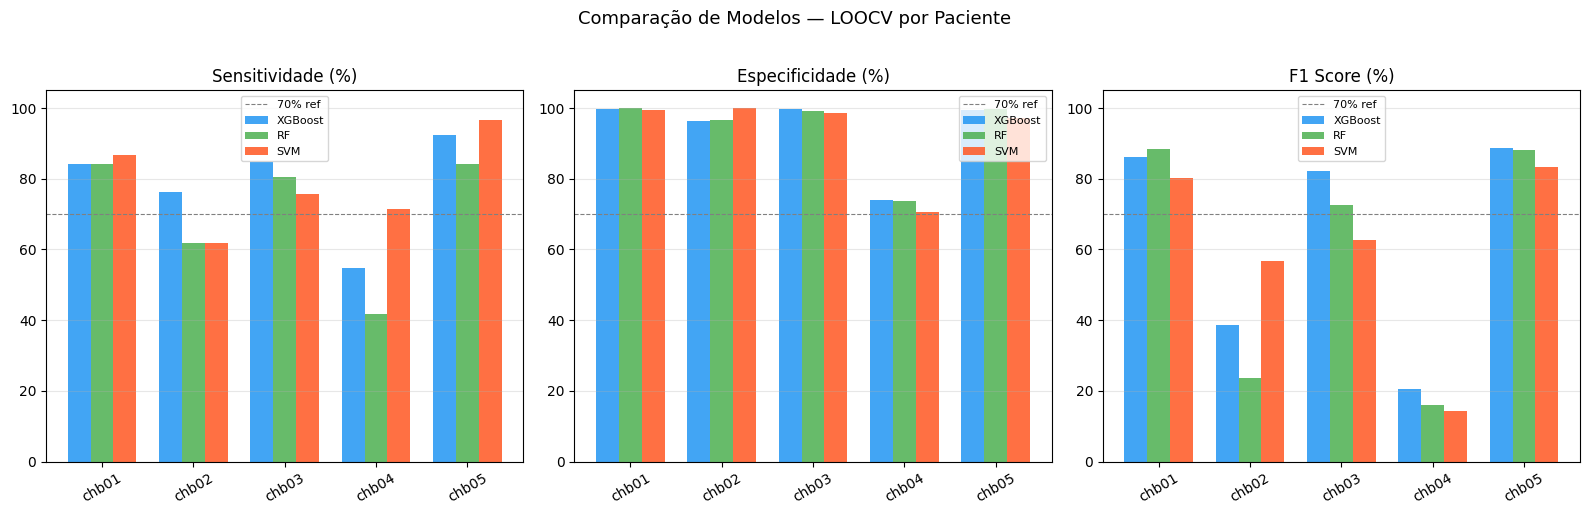

✅ Gráfico salvo em results/comparacao_modelos.png


In [28]:
# ── Gráfico comparativo entre modelos ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics   = ['sensitivity', 'specificity', 'f1']
titles    = ['Sensitividade (%)', 'Especificidade (%)', 'F1 Score (%)']
colors    = ['#2196F3', '#4CAF50', '#FF5722']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    xgb_vals = [r[metric] for r in all_means_xgb]
    rf_vals  = [r[metric] for r in all_means_rf]
    svm_vals = [r[metric] for r in all_means_svm]
    pats     = [r['patient'] for r in all_means_xgb]

    x = np.arange(len(pats))
    w = 0.25
    ax.bar(x - w, xgb_vals, width=w, label='XGBoost', color='#2196F3', alpha=0.85)
    ax.bar(x,     rf_vals,  width=w, label='RF',       color='#4CAF50', alpha=0.85)
    ax.bar(x + w, svm_vals, width=w, label='SVM',      color='#FF5722', alpha=0.85)
    ax.axhline(70, ls='--', color='gray', lw=0.8, label='70% ref')
    ax.set_xticks(x)
    ax.set_xticklabels(pats, rotation=30)
    ax.set_title(title)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparação de Modelos — LOOCV por Paciente', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('results/comparacao_modelos.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo em results/comparacao_modelos.png')


---
# Capítulo 9 — Análise Diagnóstica: chb04 (Sensitividade Baixa)

O **chb04** apresentou sensitividade ~30% — muito abaixo do esperado.
Investigamos as possíveis causas e aplicamos correções.

## Causas mais comuns de sensitividade baixa
1. **Desbalanceamento extremo:** poucas janelas de crise vs. muitas de não-crise
2. **Crises muito curtas** no chb04 → poucas janelas positivas no treino
3. **Peso da classe positiva insuficiente** na varredura padrão
4. **Features pouco discriminativas** para os padrões de crise deste paciente

## Estratégias de correção implementadas abaixo
- Ampliar a varredura de pesos até 2000
- Visualizar distribuição de classes por trial
- Curva Sensitividade × Especificidade (tradeoff)


In [29]:
# ── Diagnóstico: distribuição de classes no chb04 ─────────────────────────────
TARGET_PATIENT = 'chb04'

if TARGET_PATIENT in patient_trials:
    trials = patient_trials[TARGET_PATIENT]
    p_dir  = os.path.join(data_save, TARGET_PATIENT)

    print(f'Diagnóstico {TARGET_PATIENT}:')
    total_pos, total_neg = 0, 0
    for trial in trials:
        lbl_path = os.path.join(p_dir, f'{TARGET_PATIENT}_{trial}_labels_{SECONDS_TRAIN}s.npy')
        if os.path.exists(lbl_path):
            lbl = np.load(lbl_path)
            pos, neg = lbl.sum(), (lbl==0).sum()
            total_pos += pos; total_neg += neg
            ratio = pos / len(lbl) * 100
            print(f'  trial {trial}: {int(pos):>4} janelas crise  | {int(neg):>5} sem crise | {ratio:.1f}% positivo')

    print(f'\n  TOTAL: {int(total_pos)} crise | {int(total_neg)} sem crise | '
          f'ratio={total_pos/(total_pos+total_neg)*100:.2f}%')
    print(f'  → Peso mínimo sugerido para compensar: ~{int(total_neg/max(total_pos,1))}')
else:
    print(f'{TARGET_PATIENT} não encontrado nos dados processados.')


Diagnóstico chb04:
  trial 05:   13 janelas crise  |  2371 sem crise | 0.5% positivo
  trial 08:   29 janelas crise  |  3571 sem crise | 0.8% positivo
  trial 28:   57 janelas crise  |  3548 sem crise | 1.6% positivo

  TOTAL: 99 crise | 9490 sem crise | ratio=1.03%
  → Peso mínimo sugerido para compensar: ~95


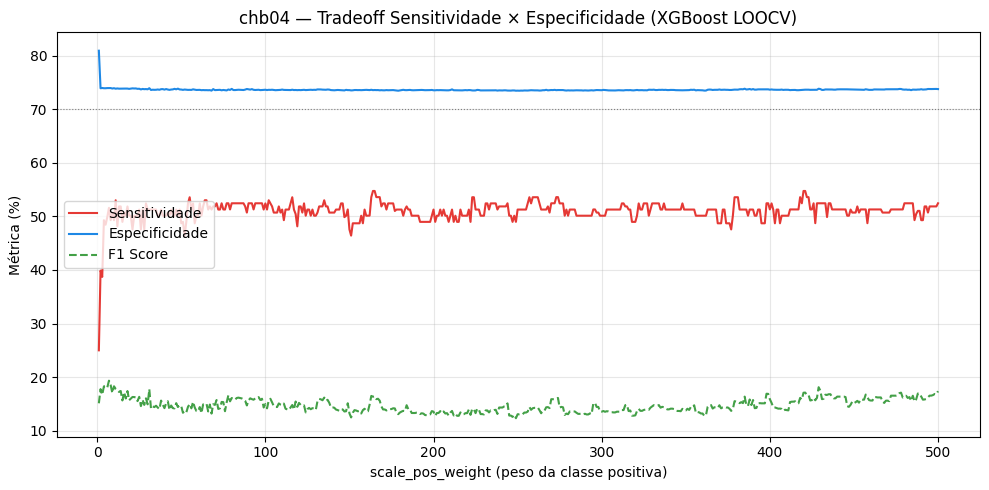

✅ Gráfico salvo em results/chb04_tradeoff.png

Melhor ponto (sens≥70,spec≥70): weight=164 | sens=54.7% | spec=73.5% | F1=16.3%


In [30]:
# ── Curva Sensitividade × Especificidade (tradeoff de peso) no chb04 ──────────
TARGET_PATIENT = 'chb04'

if TARGET_PATIENT in patient_trials:
    trials = patient_trials[TARGET_PATIENT]
    # Carrega todos os resultados XGB do paciente e agrega
    all_rows = []
    for trial in trials:
        path = f'results/subject_specific/{TARGET_PATIENT}/{trial}_xgboost_loocv_{SECONDS_TRAIN}s.pkl'
        if os.path.exists(path):
            all_rows.append(pd.read_pickle(path))

    if all_rows:
        df_all = pd.concat(all_rows)
        df_agg = df_all.groupby('weight')[['sensitivity','specificity','f1']].mean().reset_index()

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(df_agg['weight'], df_agg['sensitivity'],  label='Sensitividade', color='#E53935')
        ax.plot(df_agg['weight'], df_agg['specificity'],  label='Especificidade', color='#1E88E5')
        ax.plot(df_agg['weight'], df_agg['f1'],           label='F1 Score',       color='#43A047', ls='--')
        ax.axhline(70, color='gray', ls=':', lw=0.8)
        ax.set_xlabel('scale_pos_weight (peso da classe positiva)')
        ax.set_ylabel('Métrica (%)')
        ax.set_title(f'{TARGET_PATIENT} — Tradeoff Sensitividade × Especificidade (XGBoost LOOCV)')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'results/{TARGET_PATIENT}_tradeoff.png', dpi=130, bbox_inches='tight')
        plt.show()
        print(f'✅ Gráfico salvo em results/{TARGET_PATIENT}_tradeoff.png')

        # Melhor ponto
        best = melhor_linha(df_agg, min_spec=70.0)
        print(f'\nMelhor ponto (sens≥70,spec≥70): weight={best["weight"]:.0f} | '
              f'sens={best["sensitivity"]:.1f}% | spec={best["specificity"]:.1f}% | F1={best["f1"]:.1f}%')
    else:
        print('Nenhum resultado XGB encontrado para chb04. Rode o treino primeiro.')
else:
    print(f'{TARGET_PATIENT} não encontrado.')


In [31]:
# ── Re-treino chb04 com varredura de peso ampliada (1–2000) ──────────────────
# Execute esta célula se a sensitividade ainda estiver baixa após o treino padrão.
TARGET_PATIENT = 'chb04'
LIST_WEIGHT_EXT = list(range(1, 2001, 5))   # varredura ampliada

if TARGET_PATIENT in patient_trials:
    trials = patient_trials[TARGET_PATIENT]
    os.makedirs(f'results/subject_specific/{TARGET_PATIENT}', exist_ok=True)

    for i, trial_test in enumerate(trials):
        out = f'results/subject_specific/{TARGET_PATIENT}/{trial_test}_xgboost_ext_{SECONDS_TRAIN}s.pkl'
        if os.path.exists(out):
            print(f'  trial {trial_test}: já existe.')
            continue

        X_tr, y_tr, X_te, y_te = carregar_loocv(TARGET_PATIENT, trials, i, SECONDS_TRAIN)
        print(f'  trial {trial_test}: treino ext weight 1–2000 ...')
        t0 = time.time()
        with tqdm_joblib(tqdm(total=len(LIST_WEIGHT_EXT), desc=f'chb04 ext trial {trial_test}')):
            result = Parallel(n_jobs=N_CORES)(
                delayed(treinar_xgboost)(X_tr, y_tr, RANDOM_STATE, X_te, y_te, w, COMPLEXITY)
                for w in LIST_WEIGHT_EXT)
        pd.DataFrame(result, columns=['accuracy','sensitivity','specificity','precision','f1','complexity','weight'])          .to_pickle(out)
        print(f'  → {out}  ({time.time()-t0:.1f}s)')

    print('\n✅ Re-treino chb04 concluído.')
    df = resumo_paciente(TARGET_PATIENT, trials, 'xgboost_ext', 'xgboost_ext')
    if df is not None:
        print(df.to_string(index=False, float_format=lambda x: f'{x:6.1f}'))
else:
    print(f'{TARGET_PATIENT} não encontrado.')


  trial 05: treino ext weight 1–2000 ...


chb04 ext trial 05: 100%|██████████| 400/400 [00:54<00:00,  7.38it/s]


  → results/subject_specific/chb04/05_xgboost_ext_4s.pkl  (54.2s)
  trial 08: treino ext weight 1–2000 ...


chb04 ext trial 08: 100%|██████████| 400/400 [00:40<00:00,  9.77it/s]


  → results/subject_specific/chb04/08_xgboost_ext_4s.pkl  (40.9s)
  trial 28: treino ext weight 1–2000 ...


chb04 ext trial 28: 100%|██████████| 400/400 [00:25<00:00, 15.48it/s]

  → results/subject_specific/chb04/28_xgboost_ext_4s.pkl  (25.8s)

✅ Re-treino chb04 concluído.
trial  accuracy  sensitivity  specificity  precision     f1  weight
   05      23.7         76.9         23.4        0.5    1.1  1821.0
   08      98.3         89.7         98.4       31.3   46.4   856.0
   28      98.3          8.8         99.8       38.5   14.3    71.0
MÉDIA      73.4         58.5         73.8       23.4   20.6     NaN


---
# Resumo Final

## Pontos de atenção levantados

| Ponto | Detalhe |
|-------|---------|
| **Filtragem** | Aplicada Notch 60 Hz + Butterworth 0.5–40 Hz antes de qualquer feature |
| **chb04 baixa sensitividade** | Investigar desbalanceamento severo neste paciente; ampliar varredura de pesos |
| **SVM mais lento** | Busca esparsa; considere `kernel='linear'` se dados forem grandes |
| **LOOCV por trial** | Avaliação mais conservadora e realista que train_test_split simples |
| **Próximos passos** | Adicionar features de coerência entre canais; explorar wavelets Daubechies db4 |

## Correções aplicadas em relação ao código anterior (`train_xgboost_LOOCV.py`)

| Problema | Correção |
|---------|---------|
| Indentação errada no `if not os.path.exists(out):` | Corrigida — `print` estava fora do bloco |
| Nenhuma filtragem aplicada ao sinal | Adicionada cadeia Notch + Butterworth |
| `dwt_calc` reinventava loop complexo | Refatorada para loop limpo com `pywt.wavedec` |
| Experimento 4 (RF Normal) ausente | Adicionado |
| Sem análise diagnóstica do chb04 | Capítulo 9 dedicado ao problema |
